# @author: Dr. Manish Yadav
### Email: manish.yadav@tu-berlin.de

This code contains the functions for "Emergent E-I Structure in Performance-Evolved Reservoir Networks of
Neuronal Population Dynamics" by Manish Yadav.

In [1]:
import numpy as np
import time
import PDNE_Functions as PDNE
import Tasks
import os
import matplotlib.pyplot as plt
import networkx as nx
import pickle
import seaborn as sns
import pandas as pd

from RC_Funcs import *
from Tasks import *
from PDNE_Functions import *
from Plots import *

# 1. Define paramerters and Load WC Data

In [2]:
###### Model preparation ##############################
Informed_Growth = 'Yes' ###'No'
Delete_Nodes = 'Yes' ### 'No'  ##### Informed node deletion with 'Yes' or 'No'
InpNodeType = 0  ###### 0-> New node can be input node for other inputs as well (in multiple tasks) with Prob P_inp, 1-> Strictly exclusive to each task
OutNodeType = 0  ###### 0-> New node can be output node for other outputs as well (in multiple tasks) with Prob P_inp, 1-> Strictly exclusive to each task

##### Model Parameters ##################################
NodesDel_Percent = 20 ##### Least no. of attempts to delete nodes 
Max_AddSteps=25 ##### No. of steps the node addition function attempt, if in all steps no new node is added, t+=1

###make inital random seed network 
Nodes_init = np.array([10, 15, 25])
RandNet_init = [60, 100]
Ks= 1 
eig_rhos = 0.2 

# Net_Init = RandNetGenerator(Ks, Na, eig_rhos)

### Psi = Prob of in or out connections
### P_inp or P_out is the prob. that a new node is also an input node or not. [0, 1], 0(1)-> No(all) new nodes are inp/out nodes
MaxNewLinks = 5 
Psi=0.5  
Spectral_radius= 0.2 
T = 500 #200 ;  #### Max iterations
T_plot=25; RC_Reps=1
NetProps = [NodesDel_Percent, Max_AddSteps, MaxNewLinks, Psi, Spectral_radius]
####### Inputs and tasks###########################################################
P_inp=0.5; P_out= 1 - P_inp; 
#### Scores_Names#################################################################
Scores_Names=['NMSE train', 'NMSE pred']

####Training params#########################################################
beta = 5e-10 

Original Train Inp and Out Plot:
(6, 1, 200) (6, 2, 200) (6, 1, 200) (6, 2, 200)


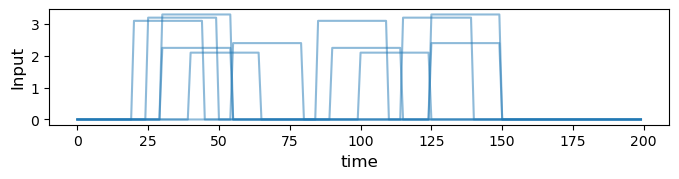

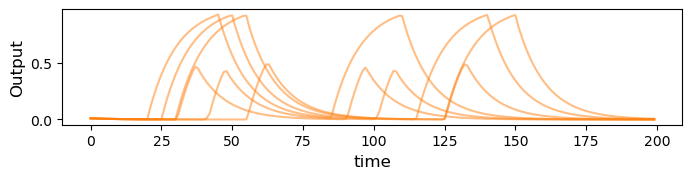

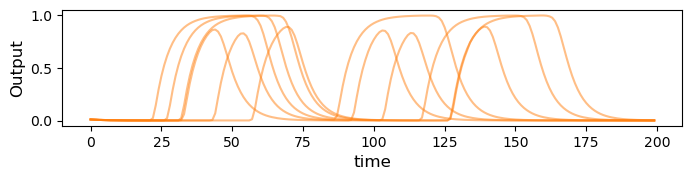

Original WC neuron Predict Inputs shape: (18, 1, 200) Predict Outputs shape: (18, 2, 200)


In [3]:
####Select the Task here#########################################################
TaskType = 'WC_Neuron'         ####Choices: 'SinCos' #'Chaos' #'VDP' #'NARMA'

####WC Neuron Task###################################################################
if TaskType=='WC_Neuron':
    alpha = 0.2 
    N_I=1; N_O=2
    
    ###g_scale random beteen [0.1, 1.0] for each node in the initial network
    # g_scale_init = list(np.random.uniform(0.01, 1.0, size=Net_Init.shape[0]))
        
    Npts_U = 3000; Transs=10
    Delta_err= 0.0075 #0.005 
    ### Desired Error and error precision (rounding off error digits for comparision)
    Err_precision= 6

    ###current directory
    try:
        DataDir = 'D:/Work/TU-Berlin/Personal/work/Cell_DigitalTwin/WC_Neuron/Data2/'
        SaveDir1 = 'D:/Work/TU-Berlin/Personal/work/Cell_DigitalTwin/WC_Neuron/Data2/Net_Init{}'.format(Nodes_init[0]) #os.path.dirname(os.path.abspath(__file__))
        SaveDir2 = 'D:/Work/TU-Berlin/Personal/work/Cell_DigitalTwin/WC_Neuron/Data2/Net_Init{}'.format(Nodes_init[1]) #os.path.dirname(os.path.abspath(__file__))
        SaveDir3 = 'D:/Work/TU-Berlin/Personal/work/Cell_DigitalTwin/WC_Neuron/Data2/Net_Init{}'.format(Nodes_init[2]) #os.path.dirname(os.path.abspath(__file__))
        RandNet_Dir1 = 'D:/Work/TU-Berlin/Personal/work/Cell_DigitalTwin/WC_Neuron/Data2/Net_Init{}'.format(RandNet_init[0]) #os.path.dirname(os.path.abspath(__file__))
        RandNet_Dir2 = 'D:/Work/TU-Berlin/Personal/work/Cell_DigitalTwin/WC_Neuron/Data2/Net_Init{}'.format(RandNet_init[1]) #os.path.dirname(os.path.abspath(__file__))
    
    except NameError:
        DataDir = os.getcwd()
    ###Data directory
    InpProps = [DataDir, 'Train']


######################################################################################  
#### Test Inp_Out Plot
print('Original Train Inp and Out Plot:')
Inps_O, Outs_O, Inps_test_O, Outs_test_O = Tasks.InpGenerate(TaskType, N_I, Npts_U, InpProps)

print(Inps_O.shape, Outs_O.shape, Inps_test_O.shape, Outs_test_O.shape)

if TaskType=='WC_Neuron':
    Tasks.InPlot_with_batches(Inps_O, Outs_O)
else:
    Tasks.InpPlot(Inps_O, Outs_O, N_I) 

###also get prediction data
InpProps_pred = [DataDir, 'Predict']
Inps_pred_Diverse_O, Outs_pred_Diverse_O = Tasks.InpGenerate('WC_Neuron', N_I, Npts_U, InpProps_pred)
print('Original WC neuron Predict Inputs shape:', Inps_pred_Diverse_O.shape, 'Predict Outputs shape:', Outs_pred_Diverse_O.shape)

In [4]:
######### Save Directory
ModelDir1 = 'D:\\Work\\TU-Berlin\\Personal\\work\\Cell_DigitalTwin\\WC_Neuron\\Data2\\Net_Init{}'.format(Nodes_init[0])
ModelDir2 = 'D:\\Work\\TU-Berlin\\Personal\\work\\Cell_DigitalTwin\\WC_Neuron\\Data2\\Net_Init{}'.format(Nodes_init[1])
ModelDir3 = 'D:\\Work\\TU-Berlin\\Personal\\work\\Cell_DigitalTwin\\WC_Neuron\\Data2\\Net_Init{}'.format(Nodes_init[2])
RandNet_Dir1 = 'D:\\Work\\TU-Berlin\\Personal\\work\\Cell_DigitalTwin\\WC_Neuron\\Data2\\Net_Init{}'.format(RandNet_init[0])
RandNet_Dir2 = 'D:\\Work\\TU-Berlin\\Personal\\work\\Cell_DigitalTwin\\WC_Neuron\\Data2\\Net_Init{}'.format(RandNet_init[1])
###loading model data
def read_gpickle_compat(file_path):
    with open(file_path, 'rb') as f:
        try:
            return pickle.load(f)
        except ValueError as e:
            # Pickle protocol 5 requires Python >= 3.8. Fallback for older kernels.
            if 'unsupported pickle protocol: 5' not in str(e):
                raise
            f.seek(0)
            try:
                import pickle5 as pickle5_module
            except ImportError as ie:
                raise RuntimeError(
                    "This file uses pickle protocol 5. Use Python 3.8+ kernel or install 'pickle5'."
                ) from ie
            return pickle5_module.load(f)
        
def LoadData(SaveDir, TaskType, Nodes_init, ModelRep):
    
    NetMsr = np.load(os.path.join(SaveDir,'{:}_{:d}_NetMeasures_Rp{:d}.npy'.format(TaskType, Nodes_init, ModelRep))) 
    Scores = np.load(os.path.join(SaveDir,'{:}_{:d}_Scores_Rp{:d}.npy'.format(TaskType, Nodes_init, ModelRep))) 
    AllInpsNodes = read_gpickle_compat(os.path.join(SaveDir,'{:}_{:d}_InpsNodes_Rp{:d}.gpickle'.format(TaskType, Nodes_init, ModelRep)))
    AllOutsNodes = read_gpickle_compat(os.path.join(SaveDir,'{:}_{:d}_OutsNodes_Rp{:d}.gpickle'.format(TaskType, Nodes_init, ModelRep)))
    AllGraphs = read_gpickle_compat(os.path.join(SaveDir,'{:}_{:d}_Graphs_Rp{:d}.gpickle'.format(TaskType, Nodes_init, ModelRep)))
    All_g_scales = read_gpickle_compat(os.path.join(SaveDir,'{:}_{:d}_g_scales_Rp{:d}.gpickle'.format(TaskType, Nodes_init, ModelRep)))
    Train_ResStates = read_gpickle_compat(os.path.join(SaveDir,'{:}_{:d}_Train_ResStates_Rp{:d}.gpickle'.format(TaskType, Nodes_init, ModelRep)))
    Pred_ResStates = read_gpickle_compat(os.path.join(SaveDir,'{:}_{:d}_Pred_ResStates_Rp{:d}.gpickle'.format(TaskType, Nodes_init, ModelRep)))
    return NetMsr, Scores, AllInpsNodes, AllOutsNodes, AllGraphs, All_g_scales, Train_ResStates, Pred_ResStates

###load final model data for model repetition 0
def LoadFinalModel(SaveDir, TaskType, Nodes_init, ModelRep, FinalModelName='Final'):
    G = read_gpickle_compat(os.path.join(SaveDir, f"{TaskType}_{Nodes_init}_{FinalModelName}_Graph_Rp{ModelRep:d}.gpickle"))
    g_scale = read_gpickle_compat(os.path.join(SaveDir, f"{TaskType}_{Nodes_init}_{FinalModelName}_g_scale_Rp{ModelRep:d}.gpickle"))
    InpsNodes = read_gpickle_compat(os.path.join(SaveDir, f"{TaskType}_{Nodes_init}_{FinalModelName}_InpsNodes_Rp{ModelRep:d}.gpickle"))
    OutsNodes = read_gpickle_compat(os.path.join(SaveDir, f"{TaskType}_{Nodes_init}_{FinalModelName}_OutsNodes_Rp{ModelRep:d}.gpickle"))
    W_outs = read_gpickle_compat(os.path.join(SaveDir, f"{TaskType}_{Nodes_init}_{FinalModelName}_W_outs_Rp{ModelRep:d}.gpickle"))
    Winps = read_gpickle_compat(os.path.join(SaveDir, f"{TaskType}_{Nodes_init}_{FinalModelName}_Winps_Rp{ModelRep:d}.gpickle"))
    Predictions = read_gpickle_compat(os.path.join(SaveDir, f"{TaskType}_{Nodes_init}_{FinalModelName}_Predictions_Rp{ModelRep:d}.gpickle"))
    Train_ResStates = read_gpickle_compat(os.path.join(SaveDir, f"{TaskType}_{Nodes_init}_{FinalModelName}_Train_ResStates_Rp{ModelRep:d}.gpickle"))
    Pred_ResStates = read_gpickle_compat(os.path.join(SaveDir, f"{TaskType}_{Nodes_init}_{FinalModelName}_Pred_ResStates_Rp{ModelRep:d}.gpickle"))
    return G, g_scale, InpsNodes, OutsNodes, W_outs[0], Winps[0], Predictions, Train_ResStates, Pred_ResStates

In [5]:
###collect the data for all Model Repetitions 
Model_Reps= 10 #10
Model_Rand_Reps = 15

def LoadFinalDiversePredModel(ModelDir, TaskType, Nodes_init, Model_Reps):
     ###collect the data for all Model Repetitions
     NetMsr_list = [];  Scores_list = [];   AllInpsNodes_list = []
     AllOutsNodes_list = [];   AllGraphs_list = [];   All_g_scales_list = []
     All_Train_ResStates = []; All_Pred_ResStates = []
     for ModelRep in range(Model_Reps):
          NetMsr, Scores, AllInpsNodes, AllOutsNodes, AllGraphs, All_g_scales, Train_ResStates, Pred_ResStates\
                 = LoadData(ModelDir, TaskType, Nodes_init, ModelRep)
          NetMsr_list.append(NetMsr); Scores_list.append(Scores)
          AllInpsNodes_list.append(AllInpsNodes); AllOutsNodes_list.append(AllOutsNodes)
          AllGraphs_list.append(AllGraphs); All_g_scales_list.append(All_g_scales)
          All_Train_ResStates.append(Train_ResStates); All_Pred_ResStates.append(Pred_ResStates)

     # NetMsr, Scores, AllInpsNodes, AllOutsNodes, AllGraphs, All_g_scales = LoadData(ModelDir, TaskType, Nodes_init, 0)
     print('NetMsr', NetMsr.shape, 'Scores', Scores.shape, 'AllInpsNodes', len(AllInpsNodes), 'AllOutsNodes', len(AllOutsNodes), 'AllGraphs', len(AllGraphs), 'All_g_scales', len(All_g_scales))
     print('Train_ResStates:', len(Train_ResStates), len(Train_ResStates[0]), len(Train_ResStates[0][0]), len(Train_ResStates[0][0][0]), 'Pred_ResStates:', len(Pred_ResStates))
     ###similarly, load final model data for all Model Repetitions
     FM_tst_NetMsr = [];  FM_tst_Scores = []
     FM_tst_InpsNodes = [];   FM_tst_OutsNodes = []
     FM_tst_Graphs = [];  FM_tst_g_scales = []
     FM_tst_W_outs = [];   FM_tst_Winps = []
     FM_tst_Predictions = []
     FM_train_ResStates=[]; FM_pred_ResStates = []
     for ModelRep in range(Model_Reps):
          G, g_scale_tst, InpsNodes_tst, OutsNodes_tst, W_outs_tst, Winps_tst, Predictions_tst, Train_ResStates_tst, Pred_ResStates_tst\
                 = LoadFinalModel(ModelDir, TaskType, Nodes_init, ModelRep, 'Final')
          FM_tst_NetMsr.append(G.number_of_nodes())
          FM_tst_Scores.append(None)  ###Scores not saved separately for final model, can be calculated if needed
          FM_tst_InpsNodes.append(InpsNodes_tst)
          FM_tst_OutsNodes.append(OutsNodes_tst)
          FM_tst_Graphs.append(G)
          FM_tst_g_scales.append(g_scale_tst)
          FM_tst_W_outs.append(W_outs_tst)
          FM_tst_Winps.append(Winps_tst)
          FM_tst_Predictions.append(Predictions_tst)
          FM_train_ResStates.append(Train_ResStates_tst)
          FM_pred_ResStates.append(Pred_ResStates_tst)

     FM_tst_Predictions = np.array(FM_tst_Predictions)[:,0,:,:,:]

     # G, g_scale_tst, InpsNodes_tst, OutsNodes_tst, W_outs_tst, Winps_tst, Predictions_tst = LoadFinalModel(ModelDir, TaskType, 0, 'Final')
     # print('Final Model Loaded: Graph with {} nodes, g_scale {}, InpsNodes {}, OutsNodes {},\
     #        W_outs shape {}, Winps shape {}'.format(G.number_of_nodes(), len(g_scale_tst), len(InpsNodes_tst), len(OutsNodes_tst), len(W_outs_tst), len(Winps_tst)))
     # print('Predictions shape:', Predictions_tst.shape)

     ###similarly, load final diverse prediction model data for all Model Repetitions
     FM_divPreds_NetMsr = [];  FM_divPreds_Scores = []
     FM_divPreds_InpsNodes = [];  FM_divPreds_OutsNodes = []
     FM_divPreds_Graphs = [];  FM_divPreds_g_scales = []
     FM_divPreds_W_outs = [];  FM_divPreds_Winps = []
     FM_divPreds_Predictions = []
     FM_divPreds_Train_ResStates = [];  FM_divPreds_Pred_ResStates = []
     for ModelRep in range(Model_Reps):
          G_f, g_scale_f, InpsNodes_f, OutsNodes_f, W_outs_f, Winps_f, Predictions_f, Train_ResStates_f, Pred_ResStates_f\
                 = LoadFinalModel(ModelDir, TaskType, Nodes_init, ModelRep, 'Final_DiversePredictions')
          FM_divPreds_NetMsr.append(G_f.number_of_nodes())
          FM_divPreds_Scores.append(None)  ###Scores not saved separately for final diverse prediction model, can be calculated if needed
          FM_divPreds_InpsNodes.append(InpsNodes_f)
          FM_divPreds_OutsNodes.append(OutsNodes_f)
          FM_divPreds_Graphs.append(G_f)
          FM_divPreds_g_scales.append(g_scale_f)
          FM_divPreds_W_outs.append(W_outs_f)
          FM_divPreds_Winps.append(Winps_f)
          FM_divPreds_Predictions.append(Predictions_f)
          FM_divPreds_Train_ResStates.append(Train_ResStates_f)
          FM_divPreds_Pred_ResStates.append(Pred_ResStates_f)

     FM_divPreds_Predictions = np.array(FM_divPreds_Predictions)[:,0,:,:,:]

     return NetMsr_list, Scores_list, AllInpsNodes_list, AllOutsNodes_list, AllGraphs_list, All_g_scales_list, \
          All_Train_ResStates, All_Pred_ResStates, \
          FM_tst_NetMsr, FM_tst_Scores, FM_tst_InpsNodes, FM_tst_OutsNodes, FM_tst_Graphs, FM_tst_g_scales, \
          FM_train_ResStates, FM_pred_ResStates, \
          FM_tst_W_outs, FM_tst_Winps, FM_tst_Predictions, FM_divPreds_NetMsr, FM_divPreds_Scores, FM_divPreds_InpsNodes, \
          FM_divPreds_Train_ResStates, FM_divPreds_Pred_ResStates, \
          FM_divPreds_OutsNodes, FM_divPreds_Graphs, FM_divPreds_g_scales, FM_divPreds_W_outs, FM_divPreds_Winps, FM_divPreds_Predictions

###load final prediction data 'final diverseprediction' models
# G_f, g_scale_f, InpsNodes_f, OutsNodes_f, W_outs_f, Winps_f, Predictions_f = LoadFinalModel(ModelDir, TaskType, Nodes_init, 0, 'Final_DiversePredictions')
# print('Final Diverse Prediction Model Loaded: Graph with {} nodes, g_scale {}, InpsNodes {}, OutsNodes {},\
#        W_outs shape {}, Winps shape {}'.format(G_f.number_of_nodes(), len(g_scale_f), len(InpsNodes_f), len(OutsNodes_f), len(W_outs_f), len(Winps_f))) 
# print('Final Diverse Predictions shape:', Predictions_f.shape)


###calling the function for Net_Init[0]

NetMsr_list0, Scores_list0, AllInpsNodes_list0, AllOutsNodes_list0, AllGraphs_list0, All_g_scales_list0, \
All_Train_ResStates0, All_Pred_ResStates0, \
FM_tst_NetMsr0, FM_tst_Scores0, FM_tst_InpsNodes0, FM_tst_OutsNodes0, FM_tst_Graphs0, FM_tst_g_scales0, \
FM_train_ResStates0, FM_pred_ResStates0, \
FM_tst_W_outs0, FM_tst_Winps0, FM_tst_Predictions0, FM_divPreds_NetMsr0, FM_divPreds_Scores0, FM_divPreds_InpsNodes0, \
FM_divPreds_Train_ResStates0, FM_divPreds_Pred_ResStates0, \
FM_divPreds_OutsNodes0, FM_divPreds_Graphs0, FM_divPreds_g_scales0, FM_divPreds_W_outs0, FM_divPreds_Winps0, FM_divPreds_Predictions0\
= LoadFinalDiversePredModel(ModelDir1, TaskType, Nodes_init[0], Model_Reps)

NetMsr_list1, Scores_list1, AllInpsNodes_list1, AllOutsNodes_list1, AllGraphs_list1, All_g_scales_list1, \
All_Train_ResStates1, All_Pred_ResStates1, \
FM_tst_NetMsr1, FM_tst_Scores1, FM_tst_InpsNodes1, FM_tst_OutsNodes1, FM_tst_Graphs1, FM_tst_g_scales1, \
FM_train_ResStates1, FM_pred_ResStates1, \
FM_tst_W_outs1, FM_tst_Winps1, FM_tst_Predictions1, FM_divPreds_NetMsr1, FM_divPreds_Scores1, FM_divPreds_InpsNodes1, \
FM_divPreds_Train_ResStates1, FM_divPreds_Pred_ResStates1, \
FM_divPreds_OutsNodes1, FM_divPreds_Graphs1, FM_divPreds_g_scales1, FM_divPreds_W_outs1, FM_divPreds_Winps1, FM_divPreds_Predictions1\
= LoadFinalDiversePredModel(ModelDir2, TaskType, Nodes_init[1], Model_Reps)

NetMsr_list2, Scores_list2, AllInpsNodes_list2, AllOutsNodes_list2, AllGraphs_list2, All_g_scales_list2, \
All_Train_ResStates2, All_Pred_ResStates2, \
FM_tst_NetMsr2, FM_tst_Scores2, FM_tst_InpsNodes2, FM_tst_OutsNodes2, FM_tst_Graphs2, FM_tst_g_scales2, \
FM_train_ResStates2, FM_pred_ResStates2, \
FM_tst_W_outs2, FM_tst_Winps2, FM_tst_Predictions2, FM_divPreds_NetMsr2, FM_divPreds_Scores2, FM_divPreds_InpsNodes2, \
FM_divPreds_Train_ResStates2, FM_divPreds_Pred_ResStates2, \
FM_divPreds_OutsNodes2, FM_divPreds_Graphs2, FM_divPreds_g_scales2, FM_divPreds_W_outs2, FM_divPreds_Winps2, FM_divPreds_Predictions2\
= LoadFinalDiversePredModel(ModelDir3, TaskType, Nodes_init[2], Model_Reps)


###joining the FM_resStates
FM_train_ResStates = FM_train_ResStates0 + FM_train_ResStates1 + FM_train_ResStates2
print(len(FM_train_ResStates), len(FM_train_ResStates[0]), len(FM_train_ResStates[0][0]), len(FM_train_ResStates[0][0][0]))

FM_pred_ResStates = FM_pred_ResStates0 + FM_pred_ResStates1 + FM_pred_ResStates2
print(len(FM_pred_ResStates), len(FM_pred_ResStates[0]), len(FM_pred_ResStates[0][0]), len(FM_pred_ResStates[0][0][0]))


####randnet data loading
NetMsr_list_R0, Scores_list_R0, AllInpsNodes_list_R0, AllOutsNodes_list_R0, AllGraphs_list_R0, All_g_scales_list_R0, \
All_Train_ResStates_R0, All_Pred_ResStates_R0, \
FM_tst_NetMsr_R0, FM_tst_Scores_R0, FM_tst_InpsNodes_R0, FM_tst_OutsNodes_R0, FM_tst_Graphs_R0, FM_tst_g_scales_R0, \
FM_train_ResStates_R0, FM_pred_ResStates_R0, \
FM_tst_W_outs_R0, FM_tst_Winps_R0, FM_tst_Predictions_R0, FM_divPreds_NetMsr_R0, FM_divPreds_Scores_R0, FM_divPreds_InpsNodes_R0, \
FM_divPreds_Train_ResStates_R0, FM_divPreds_Pred_ResStates_R0, \
FM_divPreds_OutsNodes_R0, FM_divPreds_Graphs_R0, FM_divPreds_g_scales_R0, FM_divPreds_W_outs_R0, FM_divPreds_Winps_R0, FM_divPreds_Predictions_R0\
= LoadFinalDiversePredModel(RandNet_Dir1, TaskType, RandNet_init[0], Model_Rand_Reps)

NetMsr_list_R1, Scores_list_R1, AllInpsNodes_list_R1, AllOutsNodes_list_R1, AllGraphs_list_R1, All_g_scales_list_R1, \
All_Train_ResStates_R1, All_Pred_ResStates_R1, \
FM_tst_NetMsr_R1, FM_tst_Scores_R1, FM_tst_InpsNodes_R1, FM_tst_OutsNodes_R1, FM_tst_Graphs_R1, FM_tst_g_scales_R1, \
FM_train_ResStates_R1, FM_pred_ResStates_R1, \
FM_tst_W_outs_R1, FM_tst_Winps_R1, FM_tst_Predictions_R1, FM_divPreds_NetMsr_R1, FM_divPreds_Scores_R1, FM_divPreds_InpsNodes_R1, \
FM_divPreds_Train_ResStates_R1, FM_divPreds_Pred_ResStates_R1, \
FM_divPreds_OutsNodes_R1, FM_divPreds_Graphs_R1, FM_divPreds_g_scales_R1, FM_divPreds_W_outs_R1, FM_divPreds_Winps_R1, FM_divPreds_Predictions_R1\
= LoadFinalDiversePredModel(RandNet_Dir2, TaskType, RandNet_init[1], Model_Rand_Reps)


def FirstZeroLocFinder(NetMsrs):
    ZerosLoc = np.where(NetMsrs==0)[0]
    if len(ZerosLoc)>=1:
        ZerosLocFirst=ZerosLoc[0]
    else:
        ZerosLocFirst=-1
    return ZerosLocFirst

print('rand net net measures list shape:', len(NetMsr_list_R0), 'rand net scores list shape:', len(Scores_list_R0),\
       'rand net AllInpsNodes list length:', len(AllInpsNodes_list_R0), 'rand net AllOutsNodes list length:', len(AllOutsNodes_list_R0),\
     'rand net AllGraphs list length:', len(AllGraphs_list_R0), 'rand net All_g_scales list length:', len(All_g_scales_list_R0))

NetMsr (510, 6) Scores (2, 510, 2, 2) AllInpsNodes 500 AllOutsNodes 500 AllGraphs 501 All_g_scales 501
Train_ResStates: 4 10 6 200 Pred_ResStates: 4
NetMsr (510, 6) Scores (2, 510, 2, 2) AllInpsNodes 166 AllOutsNodes 166 AllGraphs 167 All_g_scales 167
Train_ResStates: 2 15 6 200 Pred_ResStates: 2
NetMsr (510, 6) Scores (2, 510, 2, 2) AllInpsNodes 147 AllOutsNodes 147 AllGraphs 148 All_g_scales 148
Train_ResStates: 2 25 6 200 Pred_ResStates: 2
30 95 6 200
30 95 6 200
NetMsr (11, 6) Scores (2, 11, 2, 2) AllInpsNodes 1 AllOutsNodes 1 AllGraphs 2 All_g_scales 2
Train_ResStates: 2 60 6 200 Pred_ResStates: 2
NetMsr (11, 6) Scores (2, 11, 2, 2) AllInpsNodes 1 AllOutsNodes 1 AllGraphs 2 All_g_scales 2
Train_ResStates: 2 100 6 200 Pred_ResStates: 2
rand net net measures list shape: 15 rand net scores list shape: 15 rand net AllInpsNodes list length: 15 rand net AllOutsNodes list length: 15 rand net AllGraphs list length: 15 rand net All_g_scales list length: 15


NetMsrs_PDNE shape: (30, 510, 6) NetMsrs_Rand shape: (30, 6)
(30, 6) (30, 6) (30, 6)
   Nodes   Avg. CC  Avg. In_Deg  Avg. Out_Deg  Communities   Density  \
0   10.0  0.000000          1.1           1.1          3.0  0.122222   
1   10.0  0.168333          1.4           1.4          2.0  0.155556   
2   10.0  0.177778          1.1           1.1          3.0  0.122222   
3   10.0  0.108333          1.2           1.2          3.0  0.133333   
4   10.0  0.076667          1.0           1.0          4.0  0.111111   

                 Model  
0  $G_{s_{0}}$\nRandom  
1  $G_{s_{0}}$\nRandom  
2  $G_{s_{0}}$\nRandom  
3  $G_{s_{0}}$\nRandom  
4  $G_{s_{0}}$\nRandom  


C:\Users\genxm\AppData\Local\Temp\ipykernel_30492\2526508700.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Model', y=msr, data=NetMsrs_df, scale='width', inner='quartile', palette=Colors)
C:\Users\genxm\AppData\Local\Temp\ipykernel_30492\2526508700.py:34: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(x='Model', y=msr, data=NetMsrs_df, scale='width', inner='quartile', palette=Colors)
C:\Users\genxm\AppData\Local\Temp\ipykernel_30492\2526508700.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Model', y=msr, data=NetMsrs_df, scale='width', inner='quartile', palett

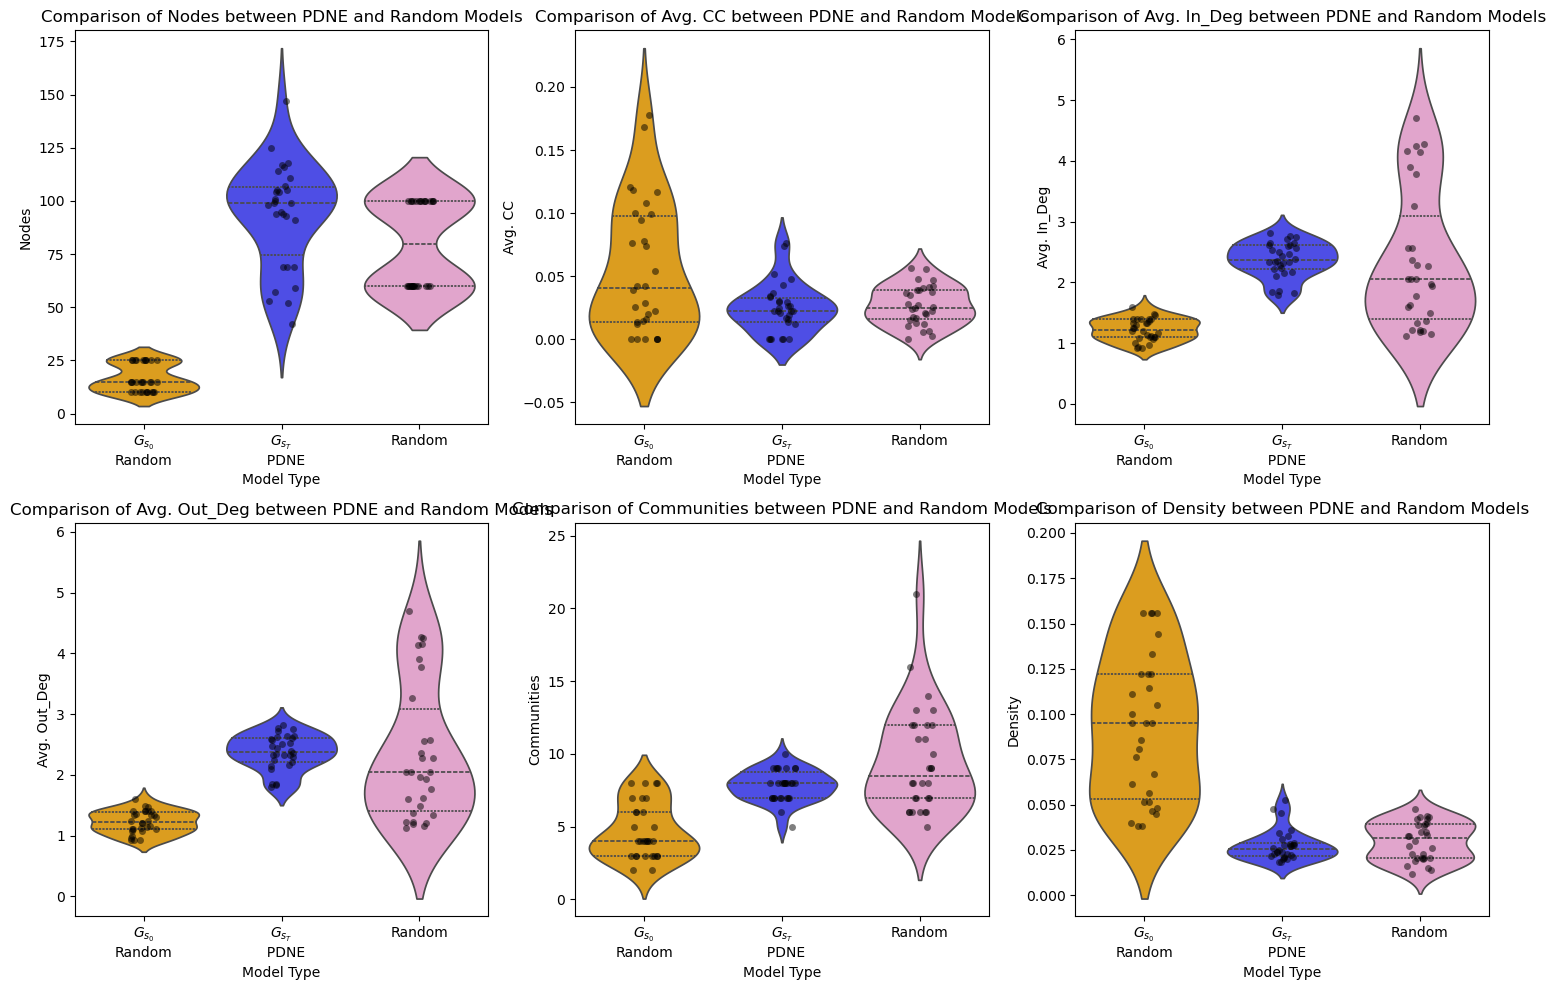

In [6]:
NetMsrs_Rand = np.array(NetMsr_list_R0 + NetMsr_list_R1)[:,0,:]
NetMsrs_PDNE_all = np.array(NetMsr_list0 + NetMsr_list1 + NetMsr_list2)
print('NetMsrs_PDNE shape:', NetMsrs_PDNE_all.shape, 'NetMsrs_Rand shape:', NetMsrs_Rand.shape)

###identify the last evolved network structrure for each model repetition in the final models using FirstZeroLocFinder function and get the corresponding network measures for those structures
NetMsrs_PDNE = np.zeros([NetMsrs_PDNE_all.shape[0], NetMsrs_PDNE_all.shape[2]])
for mdl_rp in range(NetMsrs_PDNE_all.shape[0]):
    for msr_rp in range(NetMsrs_PDNE_all.shape[2]):
        NetMsrs_PDNE[mdl_rp, msr_rp] = NetMsrs_PDNE_all[mdl_rp, FirstZeroLocFinder(NetMsrs_PDNE_all[mdl_rp, :, msr_rp])-1, msr_rp]

NetMsrs_Init = NetMsrs_PDNE_all[:, 0, :]

print(NetMsrs_Init.shape, NetMsrs_PDNE.shape, NetMsrs_Rand.shape)

###making a dataframe for the network measures of PDNE and Random models for comparison and plotting
Msr_Names = ['Nodes', 'Avg. CC', 'Avg. In_Deg', 'Avg. Out_Deg', 'Communities', 'Density']
NetMsrs_Init_df = pd.DataFrame(NetMsrs_Init, columns=Msr_Names)
NetMsrs_Init_df['Model'] = '$G_{s_{0}}$\nRandom'
NetMsrs_PDNE_df = pd.DataFrame(NetMsrs_PDNE, columns=Msr_Names)
NetMsrs_PDNE_df['Model'] = '$G_{s_{T}}$\n  PDNE'
NetMsrs_Rand_df = pd.DataFrame(NetMsrs_Rand, columns=Msr_Names)
NetMsrs_Rand_df['Model'] = 'Random' 
NetMsrs_df = pd.concat([NetMsrs_Init_df, NetMsrs_PDNE_df, NetMsrs_Rand_df], ignore_index=True)

print(NetMsrs_df.head())


#### plotting sns violin plot for net measures for each measure comparing PDNE and Random models
Colors  = ["#faa700ff", "#3535feff", "#eb9bcff8"]  # Blue for PDNE, pink for Random

plt.figure(figsize=(15, 10))
for i, msr in enumerate(Msr_Names):
    plt.subplot(2, 3, i+1)
    sns.violinplot(x='Model', y=msr, data=NetMsrs_df, scale='width', inner='quartile', palette=Colors)
    sns.stripplot(x='Model', y=msr, data=NetMsrs_df, color='k', alpha=0.5)
    plt.title(f'Comparison of {msr} between PDNE and Random Models')
    plt.xlabel('Model Type')
    plt.ylabel(msr)
    plt.tight_layout()
plt.show()


Scores_Init shape: (30, 2, 2, 2)
Scores_PDNE shape: (30, 2, 2, 2)
Scores_Rand shape: (30, 2, 2, 2)


C:\Users\genxm\AppData\Local\Temp\ipykernel_30492\2111278606.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Model', y=msr, data=NetMsrs_df, scale='width', inner='quartile', palette=Colors)
C:\Users\genxm\AppData\Local\Temp\ipykernel_30492\2111278606.py:37: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(x='Model', y=msr, data=NetMsrs_df, scale='width', inner='quartile', palette=Colors)
C:\Users\genxm\AppData\Local\Temp\ipykernel_30492\2111278606.py:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Model', y=msr, data=NetMsrs_df, scale='width', inner='quartile', palett

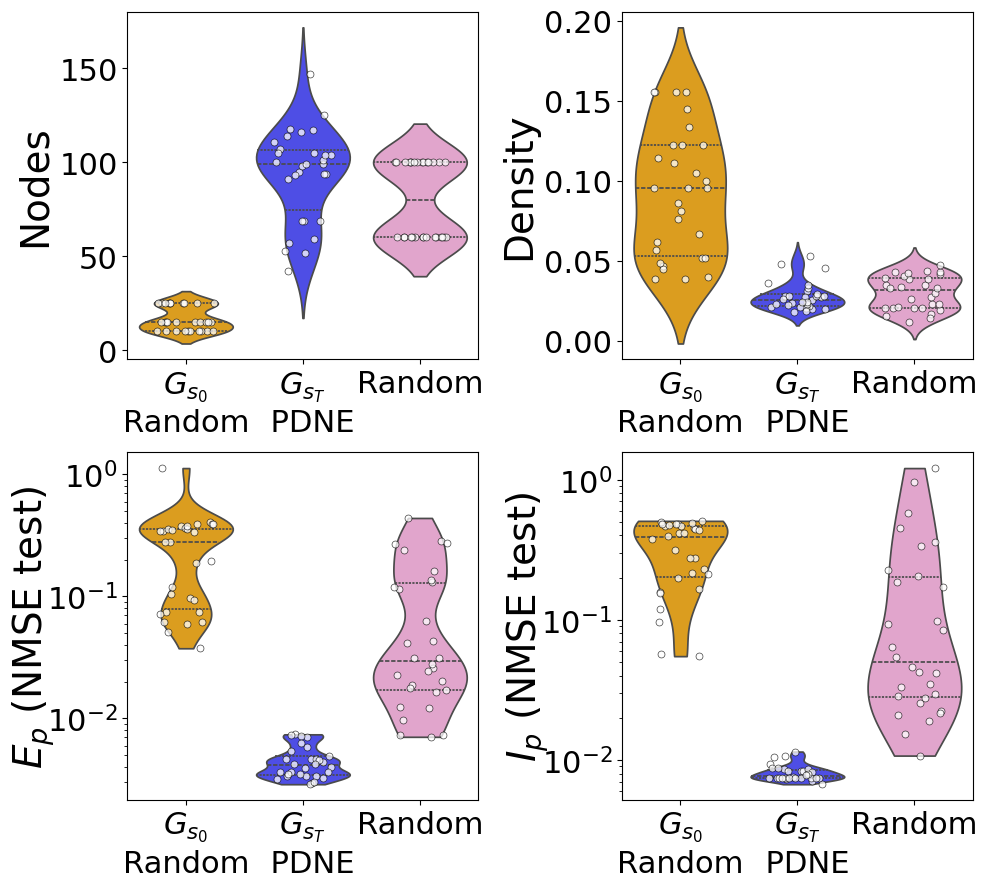

In [62]:
###also getting scores in the same way for the final models and plotting
Scores_PDNE_all = np.array(Scores_list0 + Scores_list1 + Scores_list2)

Scores_PDNE = np.zeros([Scores_PDNE_all.shape[0], Scores_PDNE_all.shape[1], Scores_PDNE_all.shape[3], Scores_PDNE_all.shape[4]])
for mdl_rp in range(Scores_PDNE_all.shape[0]):
    for sc_rp in range(Scores_PDNE_all.shape[1]):
        Scores_PDNE[mdl_rp, sc_rp, :, :] = Scores_PDNE_all[mdl_rp, sc_rp, FirstZeroLocFinder(NetMsrs_PDNE_all[mdl_rp, :, msr_rp])-1, :, :]

Scores_Init = Scores_PDNE_all[:, :, 0, :, :]
print('Scores_Init shape:', Scores_Init.shape)

print('Scores_PDNE shape:', Scores_PDNE.shape)
Scores_Rand = np.array(Scores_list_R0 + Scores_list_R1)[:,:,0,:,:]
print('Scores_Rand shape:', Scores_Rand.shape)

###making a dataframe for the scores of PDNE and Random models for comparison and plotting
###indexes are Scores_Rand shape:[model_reps 10, train or test 2, scores(NMSE, SD) 2, E(t) or I(t) score 2]
###using only NMSE score and only test for comparison
Scores_Init_test_NMSE = Scores_Init[:, 1, 0, :]
Scores_PDNE_test_NMSE = Scores_PDNE[:, 1, 0, :]
Scores_Rand_test_NMSE = Scores_Rand[:, 1, 0, :]
Scores_Init_test_NMSE_df = pd.DataFrame(Scores_Init_test_NMSE, columns=['E(t) NMSE', 'I(t) NMSE'])
Scores_Init_test_NMSE_df['Model'] = '$G_{s_{0}}$\nRandom'
Scores_PDNE_test_NMSE_df = pd.DataFrame(Scores_PDNE_test_NMSE, columns=['E(t) NMSE', 'I(t) NMSE'])
Scores_PDNE_test_NMSE_df['Model'] = '$G_{s_{T}}$\n  PDNE'
Scores_Rand_test_NMSE_df = pd.DataFrame(Scores_Rand_test_NMSE, columns=['E(t) NMSE', 'I(t) NMSE'])
Scores_Rand_test_NMSE_df['Model'] = 'Random'
Scores_df = pd.concat([Scores_Init_test_NMSE_df, Scores_PDNE_test_NMSE_df, Scores_Rand_test_NMSE_df], ignore_index=True)
# print(Scores_df)

#### plotting sns violin plot and comparing PDNE and Random models
plt.figure(figsize=(10, 9))

plt.subplot(2, 2, 1)
##make violinplot ski
msr = 'Nodes'  ##density
sns.violinplot(x='Model', y=msr, data=NetMsrs_df, scale='width', inner='quartile', palette=Colors)
sns.stripplot(x='Model', y=msr, data=NetMsrs_df,color='white', edgecolor='k', linewidth=0.5, jitter=0.25, alpha=0.75)

# sns.violinplot(x='Model', y='E(t) NMSE', data=Scores_df, color='skyblue', scale="width", \
#                inner="quartiles", bw=0.3, log_scale=True, cut=0, palette=Colors)
# sns.stripplot(x='Model', y='E(t) NMSE', data=Scores_df, color='white', edgecolor='k', linewidth=0.5, jitter=0.25, alpha=0.75)
# plt.title('Comparison of E(t) NMSE between PDNE and Random Models')
plt.xlabel('')
plt.ylabel('Nodes', fontsize=28)
###log scale for better visualization if needed
# plt.yscale('log')
plt.tick_params(axis='x', labelsize=22, labelbottom=True)
plt.tick_params(axis='y', labelsize=22)

plt.subplot(2, 2, 2)
##make violinplot ski
msr = 'Density'  ##density
sns.violinplot(x='Model', y=msr, data=NetMsrs_df, scale='width', inner='quartile', palette=Colors)
sns.stripplot(x='Model', y=msr, data=NetMsrs_df,color='white', edgecolor='k', linewidth=0.5, jitter=0.25, alpha=0.75)

# sns.violinplot(x='Model', y='E(t) NMSE', data=Scores_df, color='skyblue', scale="width", \
#                inner="quartiles", bw=0.3, log_scale=True, cut=0, palette=Colors)
# sns.stripplot(x='Model', y='E(t) NMSE', data=Scores_df, color='white', edgecolor='k', linewidth=0.5, jitter=0.25, alpha=0.75)
# plt.title('Comparison of E(t) NMSE between PDNE and Random Models')
plt.xlabel('')
plt.ylabel('Density', fontsize=28)
###log scale for better visualization if needed
# plt.yscale('log')
plt.tick_params(axis='x', labelsize=22, labelbottom=True)
plt.tick_params(axis='y', labelsize=22)

plt.subplot(2, 2, 3)
##make violinplot ski
sns.violinplot(x='Model', y='E(t) NMSE', data=Scores_df, color='skyblue', scale="width", \
               inner="quartiles", bw=0.3, log_scale=True, cut=0, palette=Colors)
sns.stripplot(x='Model', y='E(t) NMSE', data=Scores_df, color='white', edgecolor='k', linewidth=0.5, jitter=0.25, alpha=0.75)
# plt.title('Comparison of E(t) NMSE between PDNE and Random Models')
plt.xlabel('')
plt.ylabel('$E_{p}$ (NMSE test)', fontsize=28, labelpad=-7)
###log scale for better visualization if needed
plt.yscale('log')
plt.tick_params(axis='x', labelsize=22)
plt.tick_params(axis='y', labelsize=22)
# plt.tight_layout()

##increase distance between the two violins for better visibility
plt.subplots_adjust(wspace=0.3)
plt.subplots_adjust(hspace=0.25)

plt.subplot(2, 2, 4)
sns.violinplot(x='Model', y='I(t) NMSE', data=Scores_df, color='skyblue', scale="width",\
                inner="quartiles", bw=0.5, log_scale=True, cut=0, palette=Colors)
###make marker thinker with edge color as black for better visibility
sns.stripplot(x='Model', y='I(t) NMSE', data=Scores_df, color='white', edgecolor='k', linewidth=0.5, jitter=0.25, alpha=0.75)
# plt.title('Comparison of I(t) NMSE between PDNE and Random Models')
plt.xlabel('')
plt.ylabel('$I_{p}$ (NMSE test)', fontsize=28, labelpad=-7)
plt.yscale('log')
plt.tick_params(axis='x', labelsize=22)
plt.tick_params(axis='y', labelsize=22)
plt.tight_layout()
plt.savefig(f"{DataDir}/RandNet_Comparision.svg")
plt.show()

Scores_Init shape: (30, 2, 2, 2)
Scores_PDNE shape: (30, 2, 2, 2)
Scores_Rand shape: (30, 2, 2, 2)


C:\Users\genxm\AppData\Local\Temp\ipykernel_30492\567308001.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Model', y=msr, data=NetMsrs_df, scale='width', inner='quartile', palette=Colors)
C:\Users\genxm\AppData\Local\Temp\ipykernel_30492\567308001.py:37: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(x='Model', y=msr, data=NetMsrs_df, scale='width', inner='quartile', palette=Colors)
C:\Users\genxm\AppData\Local\Temp\ipykernel_30492\567308001.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Model', y=msr, data=NetMsrs_df, scale='width', inner='quartile', palette=C

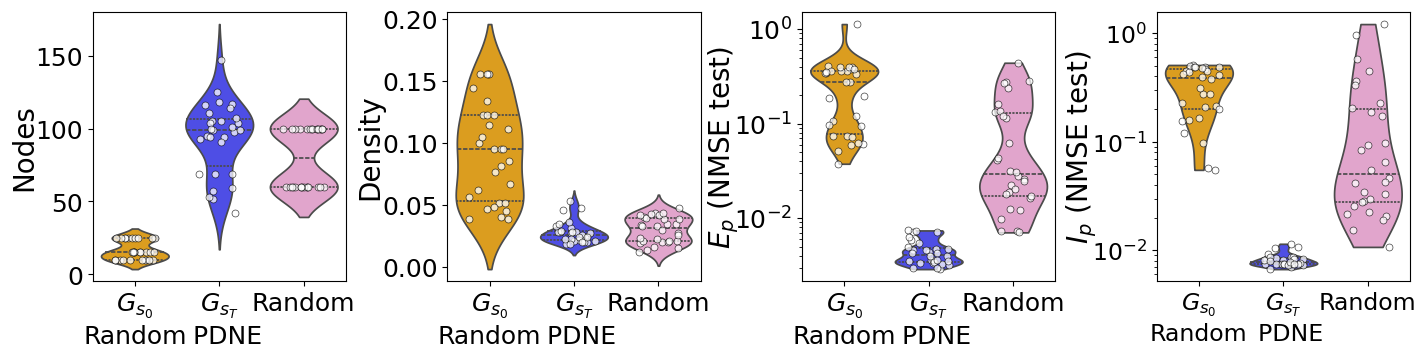

In [57]:
###also getting scores in the same way for the final models and plotting
Scores_PDNE_all = np.array(Scores_list0 + Scores_list1 + Scores_list2)

Scores_PDNE = np.zeros([Scores_PDNE_all.shape[0], Scores_PDNE_all.shape[1], Scores_PDNE_all.shape[3], Scores_PDNE_all.shape[4]])
for mdl_rp in range(Scores_PDNE_all.shape[0]):
    for sc_rp in range(Scores_PDNE_all.shape[1]):
        Scores_PDNE[mdl_rp, sc_rp, :, :] = Scores_PDNE_all[mdl_rp, sc_rp, FirstZeroLocFinder(NetMsrs_PDNE_all[mdl_rp, :, msr_rp])-1, :, :]

Scores_Init = Scores_PDNE_all[:, :, 0, :, :]
print('Scores_Init shape:', Scores_Init.shape)

print('Scores_PDNE shape:', Scores_PDNE.shape)
Scores_Rand = np.array(Scores_list_R0 + Scores_list_R1)[:,:,0,:,:]
print('Scores_Rand shape:', Scores_Rand.shape)

###making a dataframe for the scores of PDNE and Random models for comparison and plotting
###indexes are Scores_Rand shape:[model_reps 10, train or test 2, scores(NMSE, SD) 2, E(t) or I(t) score 2]
###using only NMSE score and only test for comparison
Scores_Init_test_NMSE = Scores_Init[:, 1, 0, :]
Scores_PDNE_test_NMSE = Scores_PDNE[:, 1, 0, :]
Scores_Rand_test_NMSE = Scores_Rand[:, 1, 0, :]
Scores_Init_test_NMSE_df = pd.DataFrame(Scores_Init_test_NMSE, columns=['E(t) NMSE', 'I(t) NMSE'])
Scores_Init_test_NMSE_df['Model'] = '$G_{s_{0}}$\nRandom'
Scores_PDNE_test_NMSE_df = pd.DataFrame(Scores_PDNE_test_NMSE, columns=['E(t) NMSE', 'I(t) NMSE'])
Scores_PDNE_test_NMSE_df['Model'] = '$G_{s_{T}}$\n  PDNE'
Scores_Rand_test_NMSE_df = pd.DataFrame(Scores_Rand_test_NMSE, columns=['E(t) NMSE', 'I(t) NMSE'])
Scores_Rand_test_NMSE_df['Model'] = 'Random'
Scores_df = pd.concat([Scores_Init_test_NMSE_df, Scores_PDNE_test_NMSE_df, Scores_Rand_test_NMSE_df], ignore_index=True)
# print(Scores_df)

#### plotting sns violin plot and comparing PDNE and Random models
plt.figure(figsize=(17, 3.5))

plt.subplot(1, 4, 1)
##make violinplot ski
msr = 'Nodes'  ##density
sns.violinplot(x='Model', y=msr, data=NetMsrs_df, scale='width', inner='quartile', palette=Colors)
sns.stripplot(x='Model', y=msr, data=NetMsrs_df,color='white', edgecolor='k', linewidth=0.5, jitter=0.25, alpha=0.75)

plt.xlabel('')
plt.ylabel('Nodes', fontsize=20, labelpad=-2)
###log scale for better visualization if needed
# plt.yscale('log')
plt.tick_params(axis='x', labelsize=18, labelbottom=True)
plt.tick_params(axis='y', labelsize=18)

plt.subplot(1, 4, 2)
##make violinplot ski
msr = 'Density'  ##density
sns.violinplot(x='Model', y=msr, data=NetMsrs_df, scale='width', inner='quartile', palette=Colors)
sns.stripplot(x='Model', y=msr, data=NetMsrs_df,color='white', edgecolor='k', linewidth=0.5, jitter=0.25, alpha=0.75)

plt.xlabel('')
plt.ylabel('Density', fontsize=20, labelpad=-2)
###log scale for better visualization if needed
# plt.yscale('log')
plt.tick_params(axis='x', labelsize=18, labelbottom=True)
plt.tick_params(axis='y', labelsize=18)

plt.subplot(1, 4, 3)
##make violinplot ski
sns.violinplot(x='Model', y='E(t) NMSE', data=Scores_df, color='skyblue', scale="width", \
               inner="quartiles", bw=0.3, log_scale=True, cut=0, palette=Colors)
sns.stripplot(x='Model', y='E(t) NMSE', data=Scores_df, color='white', edgecolor='k', linewidth=0.5, jitter=0.25, alpha=0.75)
# plt.title('Comparison of E(t) NMSE between PDNE and Random Models')
plt.xlabel('')
plt.ylabel('$E_{p}$ (NMSE test)', fontsize=20, labelpad=-5)
###log scale for better visualization if needed
plt.yscale('log')
plt.tick_params(axis='x', labelsize=18)
plt.tick_params(axis='y', labelsize=18)
# plt.tight_layout()

##increase distance between the two violins for better visibility


plt.subplot(1, 4, 4)
sns.violinplot(x='Model', y='I(t) NMSE', data=Scores_df, color='skyblue', scale="width",\
                inner="quartiles", bw=0.5, log_scale=True, cut=0, palette=Colors)
###make marker thinker with edge color as black for better visibility
sns.stripplot(x='Model', y='I(t) NMSE', data=Scores_df, color='white', edgecolor='k', linewidth=0.5, jitter=0.25, alpha=0.75)
# plt.title('Comparison of I(t) NMSE between PDNE and Random Models')
plt.xlabel('')
plt.ylabel('$I_{p}$ (NMSE test)', fontsize=20, labelpad=-5)
plt.yscale('log')
plt.tick_params(axis='x', labelsize=17)
plt.tick_params(axis='y', labelsize=17)
# plt.tight_layout()
plt.subplots_adjust(wspace=0.4)
# plt.subplots_adjust(hspace=0.05)
plt.savefig(f"{DataDir}/RandNet_Comparision.svg")
plt.show()